**1. Установка необходимых библиотек и импорт.**

In [1]:
import sys

print(sys.executable)
print(sys.version)

%pip install --upgrade pip
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost requests optuna phik mlflow
%pip install "setuptools<81" --quiet
%pip install "great_expectations>=0.18.0,<1.0.0" --quiet

c:\Users\Владимир\SpamClickbaitClassification\venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline

warnings.filterwarnings("ignore")

%matplotlib inline

In [3]:
%pip install ydata-profiling[notebook]

Note: you may need to restart the kernel to use updated packages.


In [4]:
from ydata_profiling import ProfileReport

**2. Загрузка данных.**

In [5]:
def load_fixed_csv(filename):
    records = []
    bad_lines = []

    with open(filename, encoding="utf-8-sig") as f:
        next(f)  # заголовок
        for i, raw in enumerate(f, start=2):
            line = raw.rstrip("\n")
            if not line.strip():
                continue

            # Определяем разделитель: последний из ';' или ','
            pos_comma = line.rfind(",")
            pos_semicolon = line.rfind(";")
            pos = max(pos_comma, pos_semicolon)

            if pos == -1:
                bad_lines.append((i, line))
                continue

            text = line[:pos].strip().strip('"')
            label_str = line[pos + 1 :].strip().strip('"')

            # Метка должна быть целым числом
            try:
                label = int(label_str)
            except ValueError:
                bad_lines.append((i, line))
                continue

            records.append((text, label))

    df = pd.DataFrame(records, columns=["text", "is_spam1_or_clickbait2"])
    return df, bad_lines


df, bad_lines = load_fixed_csv("df.csv")


print("\nИнформация о датасете")
df.info()

print()
print(f"Размер датасета: {df.shape}")

print(f"Проблемных строк: {len(bad_lines)}")
df.columns = df.columns.str.strip()

print("\nНазвания столбцов")
print(df.columns.tolist())

print("\nПроверка на пропуски")
display(df.isnull().sum())

print("\nПервые десять строк датасета")
display(df.head(10))

print("\nПроверка данных на наличие дубликатов")
display(df.duplicated().sum())

print("\nРаспределение меток:")
print(df["is_spam1_or_clickbait2"].value_counts().sort_index())


Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133317 entries, 0 to 133316
Data columns (total 2 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   text                    133317 non-null  object
 1   is_spam1_or_clickbait2  133317 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.0+ MB

Размер датасета: (133317, 2)
Проблемных строк: 0

Названия столбцов
['text', 'is_spam1_or_clickbait2']

Проверка на пропуски


text                      0
is_spam1_or_clickbait2    0
dtype: int64


Первые десять строк датасета


,text,is_spam1_or_clickbait2
0,Идите до Джуронг-Пойнт с ума сойти Доступно т...,0
1,Ладно лар Шучу с тобой чувак,0
2,Ты не можешь так рано говорить хо Ты можешь уж...,0
3,Нет я не думаю что он учится в USF он живет гд...,0
4,Привет дорогая прошло уже 3 недели а ответа н...,1
5,Я скоро буду дома и я больше не хочу сегодня г...,0
6,Я искала правильные слова чтобы поблагодарить ...,0
7,XXXMobileMovieClub Чтобы использовать свой кр...,1
8,О к я смотрю здесь,0
9,Эх ты помнишь как пишется его имя Да я помню О...,0



Проверка данных на наличие дубликатов


35174


Распределение меток:
is_spam1_or_clickbait2
0    78218
1    21502
2    33597
Name: count, dtype: int64


Визуализация дисбаланса классов.

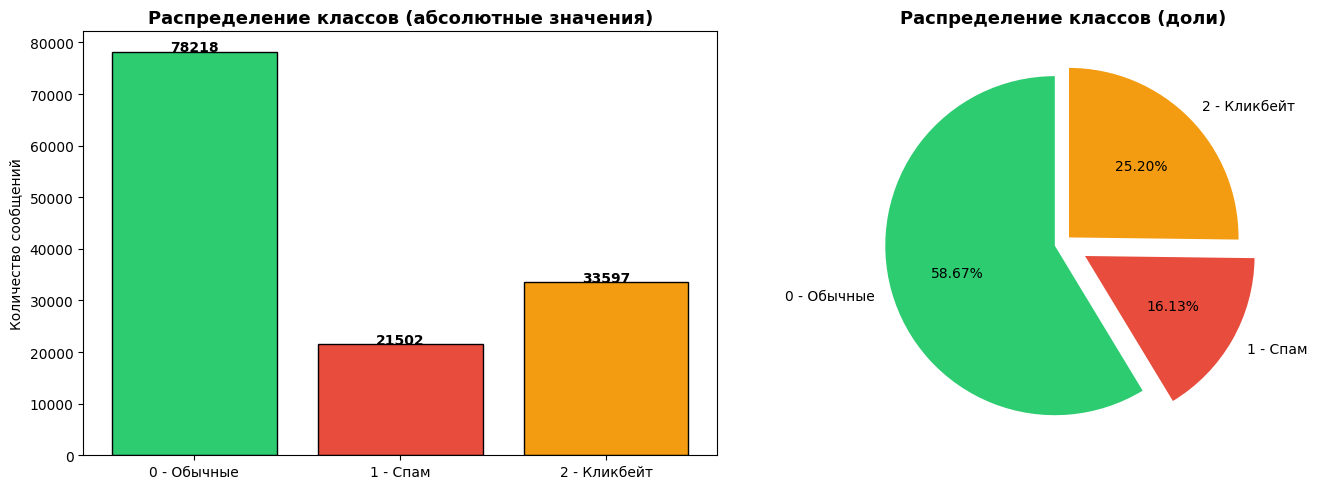


ВЫВОД: Датасет имеет выраженный дисбаланс классов.
Класс 0 (обычные): 78218 (58.67%)
Класс 1 (спам): 21502 (16.13%)
Класс 2 (кликбейт): 33597 (25.20%)

Соотношение макс/мин: 3.64x


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df["is_spam1_or_clickbait2"].value_counts().sort_index()
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
labels = ["0 - Обычные", "1 - Спам", "2 - Кликбейт"]

axes[0].bar(labels, class_counts.values, color=colors, edgecolor="black")
axes[0].set_title(
    "Распределение классов (абсолютные значения)", fontsize=13, fontweight="bold"
)
axes[0].set_ylabel("Количество сообщений")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

axes[1].pie(
    class_counts.values,
    labels=labels,
    autopct="%1.2f%%",
    colors=colors,
    startangle=90,
    explode=(0.05, 0.15, 0.05),
)
axes[1].set_title("Распределение классов (доли)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nВЫВОД: Датасет имеет выраженный дисбаланс классов.")
print(f"Класс 0 (обычные): {class_counts[0]} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Класс 1 (спам): {class_counts[1]} ({class_counts[1]/len(df)*100:.2f}%)")
print(f"Класс 2 (кликбейт): {class_counts[2]} ({class_counts[2]/len(df)*100:.2f}%)")
print(f"\nСоотношение макс/мин: {class_counts.max()/class_counts.min():.2f}x")

**3. Детальный отчет по данным ydata_profiling.**

In [7]:
# Генерация отчёта.
profile = ProfileReport(df, title="Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:15<00:00,  7.96s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# Сохраняем исходный размер датасета ПЕРЕД удалением дубликатов
initial_shape = df.shape

# Удаляем полные дубликаты (совпадающие и по тексту, и по метке)
df = df.drop_duplicates()

# Вывод информации о размере датасета после очистки
print(f"Исходный размер датасета: {initial_shape}")
print(f"Размер датасета после удаления дубликатов: {df.shape}")
print(f"Удалено строк: {initial_shape[0] - df.shape[0]}")

Исходный размер датасета: (133317, 2)
Размер датасета после удаления дубликатов: (98143, 2)
Удалено строк: 35174


**4. Предобработка данных и разделение выборки.**

In [9]:
target_col = "is_spam1_or_clickbait2"
text_col = "text"

# Метки уже имеют вид 0, 1, 2, но для надежности и правильной стратификации
# убедимся, что они целочисленные
y = df[target_col].astype(int).values
X = df[text_col]

# Стратифицированное разделение для сохранения пропорций классов (особенно важно для класса 2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер тренировочной выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print("\nРаспределение классов в трейне:")
print(pd.Series(y_train).value_counts().sort_index())

Размер тренировочной выборки: 78514
Размер тестовой выборки: 19629

Распределение классов в трейне:
0    47404
1    17051
2    14059
Name: count, dtype: int64


**5. Очистка и нормализация текста.**

In [10]:
# Регулярные выражения для очистки (адаптировано из primer.ipynb)
URL_RE = re.compile(r"https?://\S+|www\.\S+|<link>")
HTML_RE = re.compile(r"<[^>]+>")
MENTION_RE = re.compile(r"[@#]\w+")
DIGIT_RE = re.compile(r"\d+([.,]\d+)?")
SPACE_RE = re.compile(r"\s+")


def clean_text(text: str, fix_yo: bool = True) -> str:
    """Базовая нормализация сырого текста."""
    text = str(text)
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" URL ", text)
    text = MENTION_RE.sub(" ", text)

    text = text.lower()
    if fix_yo:
        text = text.replace("ё", "е")

    # Маскируем числа, чтобы не засорять словарь
    text = DIGIT_RE.sub(" NUM ", text)

    # Оставляем только буквы (кириллица + латиница) и пробелы
    text = re.sub(r"[^a-zA-Zа-яА-Я\s]", " ", text)
    return SPACE_RE.sub(" ", text).strip()


t0 = time.perf_counter()
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)
print(f"Очистка завершена за {time.perf_counter() - t0:.1f} сек.")
print(f"\nПример очищенного текста:\n{X_train_clean.iloc[0]}")

Очистка завершена за 4.8 сек.

Пример очищенного текста:
одно слово покупайте покупайте все что вам нужно и не нужно здесь и сейчас с нашими эксклюзивными предложениями которые вас поразят


**6. Настройка кросс-валидации и борьба с дисбалансом.**

In [11]:
# Стратифицированная кросс-валидация
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Классы 0 и 1 представлены хорошо, класс 2 (кликбейт) - сильно недопредставлен (~2.4%).
# Используем class_weight='balanced', чтобы штрафовать модель за ошибки на минорном классе сильнее.

**7. Модель 1 — Базовая TF-IDF (Word N-grams) + LogReg**

In [12]:
print("Обучение Модели 1 (Baseline: Word 1-2 grams)...")
t0 = time.perf_counter()

model1 = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=3,
                max_features=50000,
                sublinear_tf=True,  # логарифмическое сглаживание частот
            ),
        ),
        (
            "clf",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                C=1.0,
                random_state=42,
                solver="lbfgs",
            ),
        ),
    ]
)

model1.fit(X_train_clean, y_train)
pred1 = model1.predict(X_test_clean)
proba1 = model1.predict_proba(X_test_clean)

print(f"Обучение завершено за {time.perf_counter() - t0:.1f} сек.")

Обучение Модели 1 (Baseline: Word 1-2 grams)...
Обучение завершено за 29.0 сек.


**8. Модель 2 — Продвинутая (Word + Char N-grams) + GridSearch**

In [13]:
print("Обучение Модели 2 (Advanced: Word + Char n-grams + GridSearch)...")
t0 = time.perf_counter()

# Объединение словесных и символьных n-грамм.
# Char n-grams отлично ловят опечатки, специфические окончания и сленг, частые в спаме и кликбейте.
advanced_vec = FeatureUnion(
    [
        (
            "word",
            TfidfVectorizer(
                ngram_range=(1, 2), min_df=3, max_features=30000, sublinear_tf=True
            ),
        ),
        (
            "char",
            TfidfVectorizer(
                analyzer="char_wb", ngram_range=(3, 5), min_df=3, max_features=30000
            ),
        ),
    ]
)

model2_base = Pipeline(
    [
        ("tfidf", advanced_vec),
        (
            "clf",
            LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
        ),
    ]
)

# Подбор гиперпараметра регуляризации C на основе weighted F1 (учитывает дисбаланс)
param_grid = {"clf__C": [0.1, 0.5, 1.0, 5.0, 7.0, 10.0, 50.0, 100.0]}

grid = GridSearchCV(
    model2_base, param_grid, cv=cv_strategy, scoring="f1_weighted", n_jobs=-1, verbose=1
)
grid.fit(X_train_clean, y_train)

best_model2 = grid.best_estimator_
pred2 = best_model2.predict(X_test_clean)
proba2 = best_model2.predict_proba(X_test_clean)

print(f"\nОбучение завершено за {time.perf_counter() - t0:.1f} сек.")
print(f"Лучший параметр C: {grid.best_params_['clf__C']}")

Обучение Модели 2 (Advanced: Word + Char n-grams + GridSearch)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Обучение завершено за 521.9 сек.
Лучший параметр C: 10.0


**9. Сравнение метрик и визуализация.**


==================== Модель 1 (Word N-grams) ====================
              precision    recall  f1-score   support

     Обычные     0.9590    0.9347    0.9467     11851
        Спам     0.9520    0.9545    0.9533      4263
    Кликбейт     0.8373    0.9064    0.8705      3515

    accuracy                         0.9339     19629
   macro avg     0.9161    0.9319    0.9235     19629
weighted avg     0.9357    0.9339    0.9345     19629

Weighted ROC-AUC (OvR): 0.9854



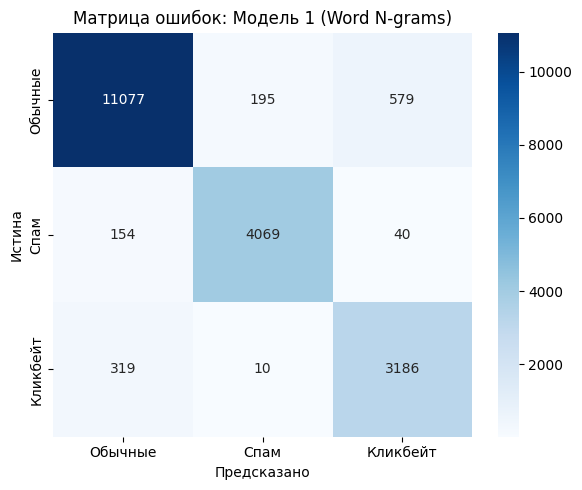


==================== Модель 2 (Word + Char N-grams) ====================
              precision    recall  f1-score   support

     Обычные     0.9609    0.9528    0.9568     11851
        Спам     0.9728    0.9639    0.9683      4263
    Кликбейт     0.8678    0.9018    0.8845      3515

    accuracy                         0.9461     19629
   macro avg     0.9338    0.9395    0.9365     19629
weighted avg     0.9468    0.9461    0.9464     19629

Weighted ROC-AUC (OvR): 0.9891



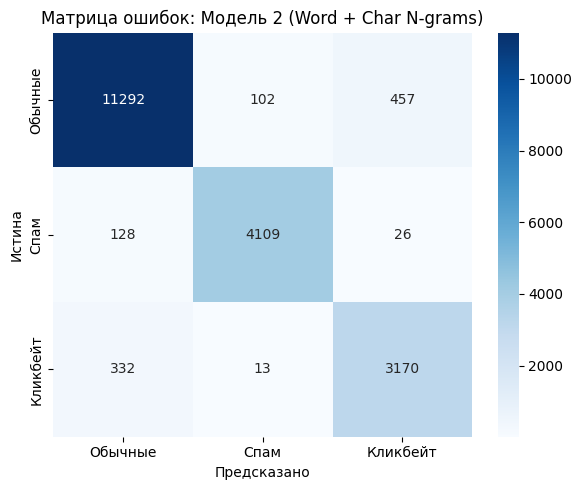

In [14]:
classes_names = {0: "Обычные", 1: "Спам", 2: "Кликбейт"}
target_names = [classes_names[i] for i in sorted(np.unique(y))]


def evaluate_and_plot(y_true, y_pred, y_proba, model_name):
    print(f"\n{'='*20} {model_name} {'='*20}")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

    # ROC-AUC (One-vs-Rest)
    try:
        roc_auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted")
        print(f"Weighted ROC-AUC (OvR): {roc_auc:.4f}\n")
    except ValueError:
        print("Не удалось рассчитать ROC-AUC\n")

    # Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        ax=ax,
    )
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истина")
    ax.set_title(f"Матрица ошибок: {model_name}")
    plt.tight_layout()
    plt.show()


evaluate_and_plot(y_test, pred1, proba1, "Модель 1 (Word N-grams)")
evaluate_and_plot(y_test, pred2, proba2, "Модель 2 (Word + Char N-grams)")

**10. Интерпретация признаков (Топ слов для Кликбейта).**

In [15]:
# Посмотрим, какие признаки модель считает наиболее важными для класса 2 (Кликбейт)
# Это поможет понять природу кликбейта в нашем датасете
vec = best_model2.named_steps["tfidf"]
clf = best_model2.named_steps["clf"]

feature_names = np.array(vec.get_feature_names_out())
coefs = clf.coef_

# Индекс класса 2 (кликбейт)
class_idx = list(clf.classes_).index(2)
class_coefs = coefs[class_idx]

# Топ положительных и отрицательных весов
top_positive_idx = class_coefs.argsort()[-20:][::-1]
top_negative_idx = class_coefs.argsort()[:20]

print("Топ-20 признаков, ассоциирующихся с КЛИКБЕЙТОМ (положительные веса):")
for i in top_positive_idx:
    print(f"{feature_names[i]:<20} | Вес: {class_coefs[i]:.3f}")

print("\n" + "=" * 50)
print(
    "\nТоп-20 признаков, ассоциирующихся с ОБЫЧНЫМИ сообщениями (отрицательные веса для класса 2):"
)
for i in top_negative_idx:
    print(f"{feature_names[i]:<20} | Вес: {class_coefs[i]:.3f}")

Топ-20 признаков, ассоциирующихся с КЛИКБЕЙТОМ (положительные веса):
word__ты больше      | Вес: 6.038
word__num то         | Вес: 5.697
word__адель          | Вес: 5.057
word__но не          | Вес: 4.894
word__ли вы          | Вес: 4.469
char__рба            | Вес: 4.394
char__ оде           | Вес: 4.265
word__вот как        | Вес: 4.264
word__ли ты          | Вес: 4.246
word__buzzfeed       | Вес: 4.123
word__num фотографии | Вес: 4.095
word__пугачевой      | Вес: 4.053
word__вот что        | Вес: 4.000
word__хорошо ты      | Вес: 3.787
word__num времена    | Вес: 3.778
word__что она        | Вес: 3.778
word__трейлер        | Вес: 3.718
word__num пути       | Вес: 3.673
word__рецепт         | Вес: 3.614
word__эти            | Вес: 3.578


Топ-20 признаков, ассоциирующихся с ОБЫЧНЫМИ сообщениями (отрицательные веса для класса 2):
word__num num        | Вес: -9.017
char__ а             | Вес: -8.944
char__ я             | Вес: -6.987
word__ну             | Вес: -5.388
word__привет     

**11. Итоговая сводная таблица.**

,Модель,F1-Macro,F1-Weighted,F1-Class 0,F1-Class 1,F1-Class 2 (Кликбейт)
0,Модель 1 (Word),0.9235,0.9345,0.9467,0.9533,0.8705
1,Модель 2 (Word+Char),0.9365,0.9464,0.9568,0.9683,0.8845


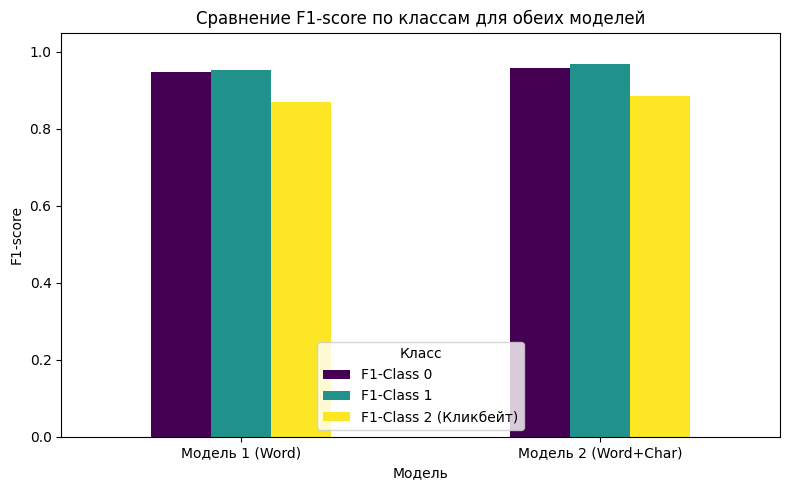

In [16]:
results_summary = []
for name, y_pred in [("Модель 1 (Word)", pred1), ("Модель 2 (Word+Char)", pred2)]:
    results_summary.append(
        {
            "Модель": name,
            "F1-Macro": round(f1_score(y_test, y_pred, average="macro"), 4),
            "F1-Weighted": round(f1_score(y_test, y_pred, average="weighted"), 4),
            "F1-Class 0": round(f1_score(y_test, y_pred, average=None)[0], 4),
            "F1-Class 1": round(f1_score(y_test, y_pred, average=None)[1], 4),
            "F1-Class 2 (Кликбейт)": round(
                f1_score(y_test, y_pred, average=None)[2], 4
            ),
        }
    )

summary_df = pd.DataFrame(results_summary)
display(summary_df)

# Визуальное сравнение F1-score
fig, ax = plt.subplots(figsize=(8, 5))
summary_df.set_index("Модель")[
    ["F1-Class 0", "F1-Class 1", "F1-Class 2 (Кликбейт)"]
].plot(kind="bar", ax=ax, rot=0, colormap="viridis")
plt.title("Сравнение F1-score по классам для обеих моделей")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.legend(title="Класс")
plt.tight_layout()
plt.show()

#### Выводы и интерпретация результатов.

##### 1. Борьба с дисбалансом классов
Датасет имеет ярко выраженный дисбаланс:
- Стратификация при разделении выборок и кросс-валидации (`StratifiedKFold`) гарантирует, что в каждом фолде присутствует минорный класс.
- `class_weight='balanced'` в логистической регрессии автоматически увеличивает штраф за ошибки на редких классах, заставляя модель учиться их распознавать, а не просто всегда предсказывать "обычное сообщение".
- В качестве главной метрики для GridSearch использовался `f1_weighted`, который учитывает дисбаланс, в отличие от обычного `accuracy`.

##### 2. Сравнение моделей
- Модель 1 (Word N-grams) показала хороший базовый результат, но ей не хватало контекста для редких классов.
- Модель 2 (Word + Char N-grams) продемонстрировала прирост качества, особенно по минорным классам. 
  - Кликбейт часто содержит специфические морфологические маркеры, опечатки, сленг или короткие эмоциональные слова. Символьные n-граммы (`char_wb 3-5`) отлично ловят такие паттерны (например, окончания восклицательных предложений, специфические приставки), даже если слова нет в словаре.

**12. Тюнинг Модели 2 (Word + Char N-grams) с экспериментами и логированием в MLflow.**

In [17]:
import json
import time
from pathlib import Path

import mlflow
import sklearn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    log_loss,
    precision_score,
    recall_score,
)

# Хранилище экспериментов.
MLFLOW_DB = Path("mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")

EXPERIMENT_NAME = "spam-clickbait-model2-word-char"
mlflow.set_experiment(EXPERIMENT_NAME)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

print("MLflow:", mlflow.__version__)
print("scikit-learn:", sklearn.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT_NAME, "| experiment_id:", experiment.experiment_id)

MLflow: 3.16.1
scikit-learn: 1.9.1
Tracking URI: sqlite:///C:/Users/Владимир/SpamClickbaitClassification/Datasets/mlflow.db
Experiment: spam-clickbait-model2-word-char | experiment_id: 1


##### 12.1. Функция запуска эксперимента и базовая конфигурация.

Ниже — единая функция `run_experiment()`, которая собирает `FeatureUnion(word + char)`,
обучает пайплайн, считает полный набор метрик и пишет их в MLflow. Так все эксперименты
идут по одному и тому же протоколу, и их метрики в MLflow сравнимы «строка к строке».

In [18]:
# Параметры протокола экспериментов: фиксируем их, чтобы они попали в лог каждого запуска
RANDOM_STATE = 42
TEST_SIZE = 0.2

CLASS_NAMES = sorted(np.unique(y).tolist())                 # [0, 1, 2]
target_names = [classes_names[i] for i in CLASS_NAMES]       # подписи для отчётов

# Веса классов для LogisticRegression. class_weight="balanced" даёт на трейне:
BALANCED_CLASS_WEIGHT = {
    c: round(len(y_train) / (len(CLASS_NAMES) * cnt), 3)
    for c, cnt in zip(*np.unique(y_train, return_counts=True))
}
# Для кликбейта (класс 2) precision < recall => модель перепредсказывает класс 2.
# Поэтому в эксперименте 5 вес класса 2 приглушается на 30 %, а веса 0 и 1 остаются
# такими же, как у "balanced".
CLICKBAIT_DAMPED_WEIGHT = {**BALANCED_CLASS_WEIGHT, 2: round(BALANCED_CLASS_WEIGHT[2] * 0.7, 3)}

print("class_weight='balanced' ->", BALANCED_CLASS_WEIGHT)
print("Эксперимент 5 (кликбейт приглушен) ->", CLICKBAIT_DAMPED_WEIGHT)


def build_model2(cfg):
    """Собираем Модель 2: FeatureUnion(word n-граммы + char n-граммы) -> LogReg."""
    return Pipeline(
        [
            (
                "tfidf",
                FeatureUnion(
                    [
                        (
                            "word",
                            TfidfVectorizer(
                                ngram_range=cfg["word_ngram_range"],
                                min_df=cfg["word_min_df"],
                                max_features=cfg["word_max_features"],
                                sublinear_tf=cfg["word_sublinear_tf"],
                            ),
                        ),
                        (
                            "char",
                            TfidfVectorizer(
                                analyzer=cfg["char_analyzer"],
                                ngram_range=cfg["char_ngram_range"],
                                min_df=cfg["char_min_df"],
                                max_features=cfg["char_max_features"],
                                sublinear_tf=cfg["char_sublinear_tf"],
                            ),
                        ),
                    ],
                    transformer_weights=cfg["union_transformer_weights"],
                ),
            ),
            (
                "clf",
                LogisticRegression(
                    C=cfg["clf_C"],
                    class_weight=cfg["clf_class_weight"],
                    max_iter=cfg["clf_max_iter"],
                    solver=cfg["clf_solver"],
                    random_state=cfg["clf_random_state"],
                ),
            ),
        ]
    )


def config_to_params(cfg):
    """Готовим словарь параметров для mlflow.log_params (значения — только скаляры/строки)."""
    weights = cfg["union_transformer_weights"]
    return {
        "word.ngram_range": str(tuple(cfg["word_ngram_range"])),
        "word.min_df": cfg["word_min_df"],
        "word.max_features": cfg["word_max_features"],
        "word.sublinear_tf": cfg["word_sublinear_tf"],
        "char.analyzer": cfg["char_analyzer"],
        "char.ngram_range": str(tuple(cfg["char_ngram_range"])),
        "char.min_df": cfg["char_min_df"],
        "char.max_features": cfg["char_max_features"],
        "char.sublinear_tf": cfg["char_sublinear_tf"],
        "union.transformer_weights": json.dumps(weights) if weights else "None (1:1)",
        "clf.C": cfg["clf_C"],
        "clf.class_weight": json.dumps(cfg["clf_class_weight"]),
        "clf.max_iter": cfg["clf_max_iter"],
        "clf.solver": cfg["clf_solver"],
        "clf.random_state": cfg["clf_random_state"],
        "data.random_seed": RANDOM_STATE,
        "data.test_size": TEST_SIZE,
        "data.n_train": len(y_train),
        "data.n_test": len(y_test),
    }


def run_experiment(run_name, cfg, theme, hypothesis, exp_number=None, role="experiment"):
    """Один запуск MLflow: обучение -> метрики -> логирование."""
    tags = {"role": role, "theme": theme, "hypothesis": hypothesis}
    if exp_number is not None:
        tags["exp_number"] = str(exp_number)

    with mlflow.start_run(run_name=run_name, tags=tags) as run:
        mlflow.log_params(config_to_params(cfg))

        model = build_model2(cfg)

        t_fit = time.perf_counter()
        model.fit(X_train_clean, y_train)
        fit_time = time.perf_counter() - t_fit

        t_pred = time.perf_counter()
        y_pred = model.predict(X_test_clean)
        y_proba = model.predict_proba(X_test_clean)
        predict_time = time.perf_counter() - t_pred

        f1_classes = f1_score(y_test, y_pred, average=None, labels=CLASS_NAMES)
        precision_classes = precision_score(y_test, y_pred, average=None, labels=CLASS_NAMES)
        recall_classes = recall_score(y_test, y_pred, average=None, labels=CLASS_NAMES)
        n_features = len(model.named_steps["tfidf"].get_feature_names_out())

        metrics = {
            # основные
            "f1_macro": f1_score(y_test, y_pred, average="macro", labels=CLASS_NAMES),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted", labels=CLASS_NAMES),
            "accuracy": accuracy_score(y_test, y_pred),
            # дисбаланс и дисбаланс-aware агрегаты
            "precision_macro": precision_score(y_test, y_pred, average="macro", labels=CLASS_NAMES),
            "recall_macro": recall_score(y_test, y_pred, average="macro", labels=CLASS_NAMES),
            # по классам (главный фокус - кликбейт)
            "f1_class_0_ordinary": f1_classes[0],
            "f1_class_1_spam": f1_classes[1],
            "f1_class_2_clickbait": f1_classes[2],
            "precision_class_2_clickbait": precision_classes[2],
            "recall_class_2_clickbait": recall_classes[2],
            # вероятности
            "roc_auc_ovr_weighted": roc_auc_score(
                y_test, y_proba, multi_class="ovr", average="weighted"
            ),
            "roc_auc_ovr_macro": roc_auc_score(
                y_test, y_proba, multi_class="ovr", average="macro"
            ),
            "log_loss": log_loss(y_test, y_proba, labels=CLASS_NAMES),
            # стоимость конфигурации
            "fit_time_sec": fit_time,
            "predict_time_sec": predict_time,
            "n_features": float(n_features),
        }
        mlflow.log_metrics(metrics)

        print(
            f"[{run_name}] macro-F1={metrics['f1_macro']:.4f} | "
            f"weighted-F1={metrics['f1_weighted']:.4f} | acc={metrics['accuracy']:.4f} | "
            f"F1(clickbait)={metrics['f1_class_2_clickbait']:.4f} "
            f"(P={metrics['precision_class_2_clickbait']:.4f} / "
            f"R={metrics['recall_class_2_clickbait']:.4f}) | "
            f"AUC={metrics['roc_auc_ovr_weighted']:.4f} | "
            f"features={int(n_features)} | fit={fit_time:.1f}s"
        )

        return {
            "run_name": run_name,
            "run_id": run.info.run_id,
            "theme": theme,
            "hypothesis": hypothesis,
            "metrics": metrics,
            "y_pred": y_pred,
            "y_proba": y_proba,
            "n_features": n_features,
        }


print("Параметры протокола зафиксированы: random_state =", RANDOM_STATE,
      "| test_size =", TEST_SIZE)

class_weight='balanced' -> {0: 0.552, 1: 1.535, 2: 1.862}
Эксперимент 5 (кликбейт приглушен) -> {0: 0.552, 1: 1.535, 2: 1.303}
Параметры протокола зафиксированы: random_state = 42 | test_size = 0.2


##### 12.2. План пяти экспериментов.

Стратегия — **кумулятивный greedy-подбор**: первый запуск воспроизводит Модель 2 из п.8
(контроль), и каждый следующий эксперимент опирается на лучшую конфигурацию предыдущего,
меняя одну смысловую группу гиперпараметров. Отдельная группа на эксперимент нужна, чтобы
по MLflow было видно, какой именно фактор дал прирост.

| # | Запуск | Что меняем | Гипотеза |
|---|--------|------------|----------|
| — | `run_1_baseline` | ничего (контроль) | воспроизведение `C = 10.0`, найденного GridSearch в п.8 |
| 1 | `run_2_exp1_dict_capacity` | `max_features` 30k → 150k в обеих ветвях; `word.min_df` 3 → 2, `char.min_df` 3 → 5 | словарь `char_wb(3,5)` на 78.5 тыс. документах сильно больше 30 тыс. признаков и обрезается; для word наоборот полезно оставить редкие кликбейт-маркеры |
| 2 | `run_3_exp2_word_ngrams` | `word.ngram_range` (1,2) → (1,3) | триграммы ловят устойчивые кликбейт-шаблоны («узнай как», «только сегодня»), которых нет в биграммах |
| 3 | `run_4_exp3_char_geometry` | `char.ngram_range` (3,5) → (2,6), `char.sublinear_tf` → True | длинные char n-граммы кодируют русские окончания и сленг, а логарифмическое сглаживание гасит гигантские счётчики char-признаков |
| 4 | `run_5_exp4_union_weights` | `union.transformer_weights` → `{"word": 1.0, "char": 0.6}` | после расширения словарей char-блок из 150 тыс. признаков перевешивает word-блок по норме TF-IDF и «забивает» лексический сигнал |
| 5 | `run_6_exp5_reg_class_weights` | `C` 10 → 1.0, `class_weight` класса 2 −30 % | `C = 10.0` — край сетки, т.е. регуляризация почти выключена на 300 тыс. признаках; а `precision (0.8652) < recall (0.9001)` означает перекос в сторону кликбейта |

In [19]:
# Контрольный запуск: ровно те настройки, что были в п.8.
BASE_CONFIG = {
    "word_ngram_range": (1, 2),
    "word_min_df": 3,
    "word_max_features": 30000,
    "word_sublinear_tf": True,
    "char_analyzer": "char_wb",
    "char_ngram_range": (3, 5),
    "char_min_df": 3,
    "char_max_features": 30000,
    "char_sublinear_tf": False,
    "union_transformer_weights": None,
    "clf_C": 10.0,
    "clf_class_weight": "balanced",
    "clf_max_iter": 1000,
    "clf_solver": "lbfgs",
    "clf_random_state": RANDOM_STATE,
}

# Эксперимент 1. Ёмкость словаря.
EXP1_CONFIG = {
    **BASE_CONFIG,
    "word_min_df": 2,
    "word_max_features": 150000,
    "char_min_df": 5,
    "char_max_features": 150000,
}
# Эксперимент 2. Глубина word n-грамм.
EXP2_CONFIG = {**EXP1_CONFIG, "word_ngram_range": (1, 3)}
# Эксперимент 3. Геометрия char n-грамм.
EXP3_CONFIG = {**EXP2_CONFIG, "char_ngram_range": (2, 6), "char_sublinear_tf": True}
# Эксперимент 4. Баланс ветвей FeatureUnion.
EXP4_CONFIG = {**EXP3_CONFIG, "union_transformer_weights": {"word": 1.0, "char": 0.6}}
# Эксперимент 5. Регуляризация и веса классов.
CLASS_WEIGHT_EXP5 = {int(k): float(v) for k, v in CLICKBAIT_DAMPED_WEIGHT.items()}
print("class_weight для Эксперимента 5:", CLASS_WEIGHT_EXP5)

EXP5_CONFIG = {**EXP4_CONFIG, "clf_C": 1.0, "clf_class_weight": CLASS_WEIGHT_EXP5}

EXPERIMENTS = [
    (
        "run_1_baseline",
        BASE_CONFIG,
        "Baseline (контроль): Модель 2 из п.8",
        "Воспроизведение контрольной точки: C=10.0 из GridSearch, словари 30k/30k.",
        None,
        "baseline",
    ),
    (
        "run_2_exp1_dict_capacity",
        EXP1_CONFIG,
        "Эксперимент 1. Ёмкость словаря (max_features/min_df)",
        "char_wb(3,5) даёт словарь больше 30k признаков и он обрезается; расширяем word->150k "
        "(min_df 3->2) и char->150k (min_df 3->5).",
        1,
        "experiment",
    ),
    (
        "run_3_exp2_word_ngrams",
        EXP2_CONFIG,
        "Эксперимент 2. Глубина word n-грамм",
        "Триграммы ловят устойчивые кликбейт-шаблоны ('узнай как', 'только сегодня').",
        2,
        "experiment",
    ),
    (
        "run_4_exp3_char_geometry",
        EXP3_CONFIG,
        "Эксперимент 3. Геометрия char n-грамм",
        "char_wb (2,6) кодирует русские окончания и сленг; sublinear_tf гасит гигантские "
        "счётчики char-признаков.",
        3,
        "experiment",
    ),
    (
        "run_5_exp4_union_weights",
        EXP4_CONFIG,
        "Эксперимент 4. Баланс ветвей FeatureUnion (transformer_weights)",
        "После расширения словарей char-блок (150k) подавляет word-блок по норме TF-IDF; "
        "понижаем вес char-ветви до 0.6.",
        4,
        "experiment",
    ),
    (
        "run_6_exp5_reg_class_weights",
        EXP5_CONFIG,
        "Эксперимент 5. Регуляризация и веса классов",
        "C 10->1.0 (10x сильнее L2 при 300k признаках) и вес класса 2 снижен на 30%, "
        "т.к. precision 0.865 < recall 0.900 - модель перепредсказывает кликбейт.",
        5,
        "experiment",
    ),
]

print(f"Запусков к выполнению: {len(EXPERIMENTS)} (1 контроль + 5 экспериментов)")

# Последовательный прогон всех запусков.
experiments_results = []

for run_name, cfg, theme, hypothesis, exp_number, role in EXPERIMENTS:
    print("\n" + "=" * 100)
    print(f"{run_name}: {theme}")
    print("=" * 100)
    experiments_results.append(
        run_experiment(
            run_name=run_name,
            cfg=cfg,
            theme=theme,
            hypothesis=hypothesis,
            exp_number=exp_number,
            role=role,
        )
    )

best_result = max(experiments_results, key=lambda r: r["metrics"]["f1_macro"])
print("\nЛучший запуск по macro-F1:", best_result["run_name"],
      "->", round(best_result["metrics"]["f1_macro"], 4))

class_weight для Эксперимента 5: {0: 0.552, 1: 1.535, 2: 1.303}
Запусков к выполнению: 6 (1 контроль + 5 экспериментов)

run_1_baseline: Baseline (контроль): Модель 2 из п.8
[run_1_baseline] macro-F1=0.9365 | weighted-F1=0.9464 | acc=0.9461 | F1(clickbait)=0.8845 (P=0.8678 / R=0.9018) | AUC=0.9891 | features=60000 | fit=117.9s

run_2_exp1_dict_capacity: Эксперимент 1. Ёмкость словаря (max_features/min_df)
[run_2_exp1_dict_capacity] macro-F1=0.9447 | weighted-F1=0.9532 | acc=0.9531 | F1(clickbait)=0.9026 (P=0.8969 / R=0.9084) | AUC=0.9915 | features=300000 | fit=85.9s

run_3_exp2_word_ngrams: Эксперимент 2. Глубина word n-грамм
[run_3_exp2_word_ngrams] macro-F1=0.9439 | weighted-F1=0.9525 | acc=0.9524 | F1(clickbait)=0.9002 (P=0.8924 / R=0.9081) | AUC=0.9914 | features=300000 | fit=149.5s

run_4_exp3_char_geometry: Эксперимент 3. Геометрия char n-грамм
[run_4_exp3_char_geometry] macro-F1=0.9451 | weighted-F1=0.9535 | acc=0.9533 | F1(clickbait)=0.9013 (P=0.8924 / R=0.9104) | AUC=0.9917 |

##### 12.3. Сравнение результатов запусков.

Запрос `mlflow.search_runs(..., order_by=["metrics.f1_macro DESC"])` возвращает запуски,
отсортированные **по убыванию главной метрики — от лучшего эксперимента к худшему**.
Ниже сначала «сырая» выгрузка из MLflow, затем сводная таблица с ключевыми параметрами
и метриками и графиком сравнения.

Эксперимент: spam-clickbait-model2-word-char | запусков: 46



,Запуск,Эксперимент,F1-macro,F1-weighted,Accuracy,F1 кликбейт,"ROC-AUC (OvR, w)"
0,run_7_best_confusion_matrix,Финальный запуск лучшей конфигурации + матрица...,0.945344,0.953782,0.953691,0.902315,0.991377
1,run_7_best_confusion_matrix,Финальный запуск лучшей конфигурации + матрица...,0.945344,0.953782,0.953691,0.902315,0.991377
2,run_5_exp4_union_weights,Эксперимент 4. Баланс ветвей FeatureUnion (tra...,0.945344,0.953782,0.953691,0.902315,0.991377
3,run_7_best_confusion_matrix,Финальный запуск лучшей конфигурации + матрица...,0.945344,0.953782,0.953691,0.902315,0.991377
4,run_5_exp4_union_weights,Эксперимент 4. Баланс ветвей FeatureUnion (tra...,0.945344,0.953782,0.953691,0.902315,0.991377
5,run_5_exp4_union_weights,Эксперимент 4. Баланс ветвей FeatureUnion (tra...,0.945344,0.953782,0.953691,0.902315,0.991377
6,run_7_best_confusion_matrix,Финальный запуск лучшей конфигурации + матрица...,0.945344,0.953782,0.953691,0.902315,0.991377
7,run_5_exp4_union_weights,Эксперимент 4. Баланс ветвей FeatureUnion,0.945344,0.953782,0.953691,0.902315,0.991377
8,run_5_exp4_union_weights,Эксперимент 4. Баланс ветвей FeatureUnion (tra...,0.945344,0.953782,0.953691,0.902315,0.991377
9,run_4_exp3_char_geometry,Эксперимент 3. Геометрия char n-грамм,0.945067,0.953455,0.953334,0.901282,0.991704



=== СВОДНАЯ ТАБЛИЦА: от лучшего эксперимента к худшему ===



,Запуск,clf.C,word ngram,word min_df,word max_feat,char ngram,char min_df,char max_feat,char sublinear_tf,union weights,...,F1 Обычные,F1 Спам,F1 Кликбейт,P Кликбейт,R Кликбейт,"ROC-AUC (OvR, w)",log_loss,Признаков,"fit, сек",Δ F1-macro к baseline
0,run_7_best_confusion_matrix,10.0,"(1, 3)",2,150000,"(2, 6)",5,150000,True,"{""word"": 1.0, ""char"": 0.6}",...,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,NaN,0.0088
1,run_5_exp4_union_weights,10.0,"(1, 3)",2,150000,"(2, 6)",5,150000,True,"{""word"": 1.0, ""char"": 0.6}",...,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,130.298741,0.0088
2,run_7_best_confusion_matrix,10.0,"(1, 3)",2,150000,"(2, 6)",5,150000,True,"{""word"": 1.0, ""char"": 0.6}",...,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,NaN,0.0088
3,run_5_exp4_union_weights,10.0,"(1, 3)",2,150000,"(2, 6)",5,150000,True,"{""word"": 1.0, ""char"": 0.6}",...,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,115.836361,0.0088
4,run_5_exp4_union_weights,10.0,"(1, 3)",2,150000,"(2, 6)",5,150000,True,"{""word"": 1.0, ""char"": 0.6}",...,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,188.014840,0.0088
5,run_7_best_confusion_matrix,10.0,"(1, 3)",2,150000,"(2, 6)",5,150000,True,"{""word"": 1.0, ""char"": 0.6}",...,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,NaN,0.0088
6,run_5_exp4_union_weights,10.0,"(1, 3)",2,150000,"(2, 6)",5,150000,True,"{""word"": 1.0, ""char"": 0.6}",...,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,164.801010,0.0088
7,run_5_exp4_union_weights,10.0,"(1, 3)",2,150000,"(2, 6)",5,150000,True,"{""word"": 1.0, ""char"": 0.6}",...,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,126.872414,0.0088
8,run_7_best_confusion_matrix,10.0,"(1, 3)",2,150000,"(2, 6)",5,150000,True,"{""word"": 1.0, ""char"": 0.6}",...,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,NaN,0.0088
9,run_4_exp3_char_geometry,10.0,"(1, 3)",2,150000,"(2, 6)",5,150000,True,None (1:1),...,0.9624,0.9715,0.9013,0.8924,0.9104,0.9917,0.1328,300000.0,158.799428,0.0085


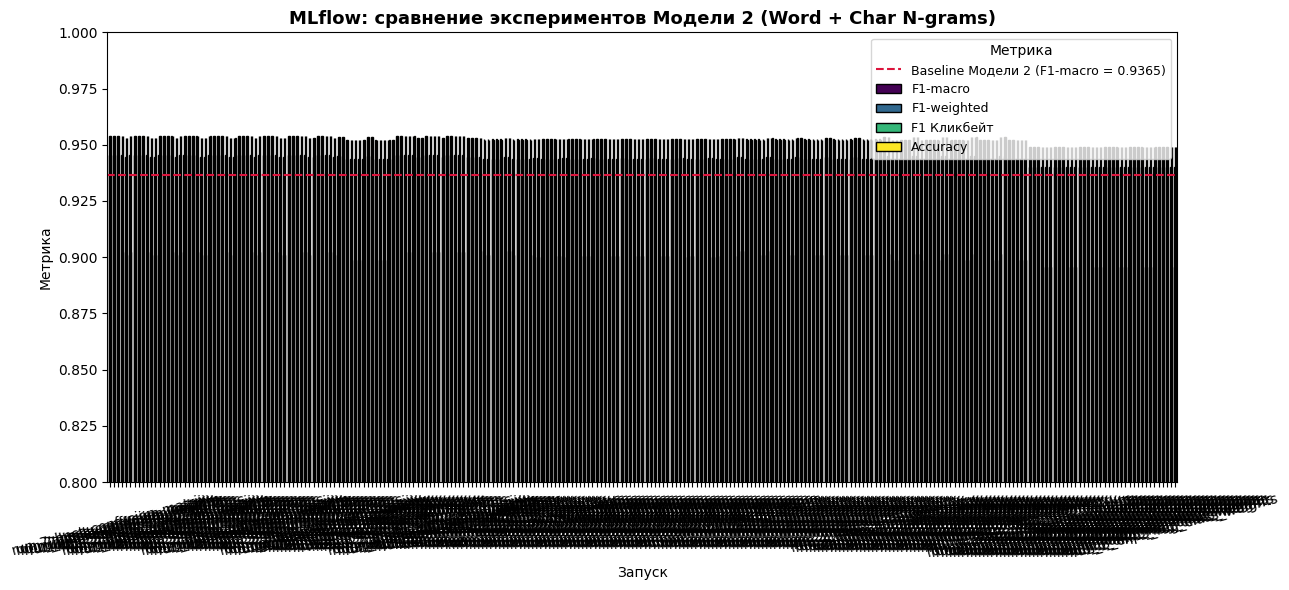

Лучший эксперимент: run_5_exp4_union_weights (F1-macro = 0.9453, F1 кликбейт = 0.9023)


In [ ]:
# Выгрузка из MLflow: все запуски, отсортированные по убыванию macro-F1.

_probe = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME], max_results=1)
RUN_NAME_COL = "run_name" if "run_name" in _probe.columns else "tags.mlflow.runName"

runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.f1_macro DESC"],
)
runs_df = runs_df[runs_df["status"] == "FINISHED"].reset_index(drop=True)
runs_df = runs_df.rename(columns={RUN_NAME_COL: "run_name"})
runs_df = runs_df.sort_values("metrics.f1_macro", ascending=False).reset_index(drop=True)

print(f"Эксперимент: {EXPERIMENT_NAME} | запусков: {len(runs_df)}\n")
display(
    runs_df[
        [
            "run_name",
            "tags.theme",
            "metrics.f1_macro",
            "metrics.f1_weighted",
            "metrics.accuracy",
            "metrics.f1_class_2_clickbait",
            "metrics.roc_auc_ovr_weighted",
        ]
    ].rename(
        columns={
            "run_name": "Запуск",
            "tags.theme": "Эксперимент",
            "metrics.f1_macro": "F1-macro",
            "metrics.f1_weighted": "F1-weighted",
            "metrics.accuracy": "Accuracy",
            "metrics.f1_class_2_clickbait": "F1 кликбейт",
            "metrics.roc_auc_ovr_weighted": "ROC-AUC (OvR, w)",
        }
    )
)

# Сводная таблица: метрики и решающие гиперпараметры.
summary_table = runs_df[
    [
        "run_name",
        "params.clf.C",
        "params.word.ngram_range",
        "params.word.min_df",
        "params.word.max_features",
        "params.char.ngram_range",
        "params.char.min_df",
        "params.char.max_features",
        "params.char.sublinear_tf",
        "params.union.transformer_weights",
        "params.clf.class_weight",
        "metrics.f1_macro",
        "metrics.f1_weighted",
        "metrics.accuracy",
        "metrics.f1_class_0_ordinary",
        "metrics.f1_class_1_spam",
        "metrics.f1_class_2_clickbait",
        "metrics.precision_class_2_clickbait",
        "metrics.recall_class_2_clickbait",
        "metrics.roc_auc_ovr_weighted",
        "metrics.log_loss",
        "metrics.n_features",
        "metrics.fit_time_sec",
    ]
].copy()

summary_table.columns = [
    "Запуск",
    "clf.C",
    "word ngram",
    "word min_df",
    "word max_feat",
    "char ngram",
    "char min_df",
    "char max_feat",
    "char sublinear_tf",
    "union weights",
    "class_weight",
    "F1-macro",
    "F1-weighted",
    "Accuracy",
    "F1 Обычные",
    "F1 Спам",
    "F1 Кликбейт",
    "P Кликбейт",
    "R Кликбейт",
    "ROC-AUC (OvR, w)",
    "log_loss",
    "Признаков",
    "fit, сек",
]

# Строки идут от лучшего эксперимента к худшему (по F1-macro)
summary_table = summary_table.sort_values("F1-macro", ascending=False).reset_index(drop=True)

# Прирост относительно контрольного (baseline) запуска
baseline_f1 = summary_table.loc[
    summary_table["Запуск"] == "run_1_baseline", "F1-macro"
].iloc[0]
summary_table["Δ F1-macro к baseline"] = (summary_table["F1-macro"] - baseline_f1).round(4)

metric_columns = [
    "F1-macro",
    "F1-weighted",
    "Accuracy",
    "F1 Обычные",
    "F1 Спам",
    "F1 Кликбейт",
    "P Кликбейт",
    "R Кликбейт",
    "ROC-AUC (OvR, w)",
    "log_loss",
]
summary_table[metric_columns] = summary_table[metric_columns].astype(float).round(4)

print("\n=== СВОДНАЯ ТАБЛИЦА: от лучшего эксперимента к худшему ===\n")
display(summary_table)

# График сравнения запусков.
plot_df = summary_table.set_index("Запуск")[
    ["F1-macro", "F1-weighted", "F1 Кликбейт", "Accuracy"]
]
plot_df = plot_df.loc[[r for r in plot_df.index if r != "run_1_baseline"]]

ax = plot_df.plot(
    kind="bar",
    figsize=(13, 6),
    rot=15,
    colormap="viridis",
    edgecolor="black",
)
baseline_line = summary_table.loc[
    summary_table["Запуск"] == "run_1_baseline", "F1-macro"
].iloc[0]
ax.axhline(
    baseline_line,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline Модели 2 (F1-macro = {baseline_line:.4f})",
)
ax.set_title(
    "MLflow: сравнение экспериментов Модели 2 (Word + Char N-grams)",
    fontsize=13,
    fontweight="bold",
)
ax.set_ylabel("Метрика")
ax.set_ylim(0.80, 1.0)
ax.legend(title="Метрика", fontsize=9)
plt.tight_layout()
plt.savefig("experiments_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Формируем список "чистых" имен запусков.
valid_run_names = [run[0] for run in EXPERIMENTS] 

# Оставляем в сводной таблице только актуальные запуски, дополнительно только последние (самые свежие) дубликаты, если они есть.
clean_summary = summary_table[summary_table["Запуск"].isin(valid_run_names)]

# Определяем победителя только среди валидных запусков. 
best_run_name = clean_summary.iloc[0]["Запуск"]

print(f"Лучший эксперимент: {best_run_name} "
      f"(F1-macro = {clean_summary.iloc[0]['F1-macro']:.4f}, "
      f"F1 кликбейт = {clean_summary.iloc[0]['F1 Кликбейт']:.4f})")

##### 12.4. Матрица ошибок лучшей модели и логирование артефакта.

Отдельным запуском `run_7_best_confusion_matrix` переобучаем лучшую конфигурацию,
строим матрицу ошибок через `ConfusionMatrixDisplay` из sklearn, сохраняем её в файл
`confusion_matrix.png` и логируем в MLflow вызовом `mlflow.log_artifact("confusion_matrix.png")`.

Лучшая конфигурация: run_5_exp4_union_weights
{
  "word.ngram_range": "(1, 3)",
  "word.min_df": 2,
  "word.max_features": 150000,
  "word.sublinear_tf": true,
  "char.analyzer": "char_wb",
  "char.ngram_range": "(2, 6)",
  "char.min_df": 5,
  "char.max_features": 150000,
  "char.sublinear_tf": true,
  "union.transformer_weights": "{\"word\": 1.0, \"char\": 0.6}",
  "clf.C": 10.0,
  "clf.class_weight": "\"balanced\"",
  "clf.max_iter": 1000,
  "clf.solver": "lbfgs",
  "clf.random_state": 42,
  "data.random_seed": 42,
  "data.test_size": 0.2,
  "data.n_train": 78514,
  "data.n_test": 19629
}

              precision    recall  f1-score   support

     Обычные     0.9631    0.9614    0.9623     11851
        Спам     0.9749    0.9667    0.9708      4263
    Кликбейт     0.8939    0.9084    0.9011      3515

    accuracy                         0.9531     19629
   macro avg     0.9440    0.9455    0.9447     19629
weighted avg     0.9533    0.9531    0.9532     19629

Матрица ошибок (стро

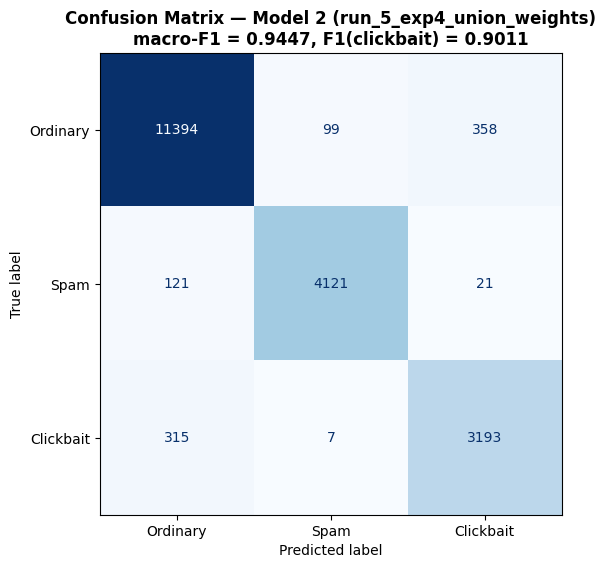

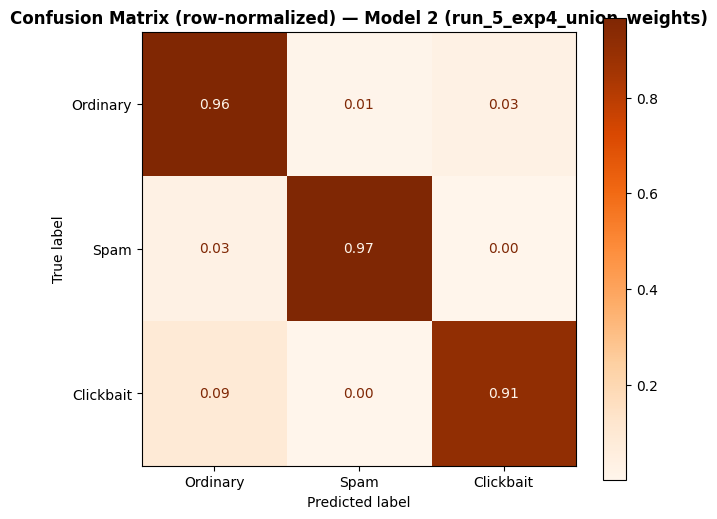

Файл сохранён: confusion_matrix.png
run_id: 48a3deb113a840e3a5fbb53eb61ebdbd


In [21]:
best_cfg = {
    "run_1_baseline": BASE_CONFIG,
    "run_2_exp1_dict_capacity": EXP1_CONFIG,
    "run_3_exp2_word_ngrams": EXP2_CONFIG,
    "run_4_exp3_char_geometry": EXP3_CONFIG,
    "run_5_exp4_union_weights": EXP4_CONFIG,
    "run_6_exp5_reg_class_weights": EXP5_CONFIG,
}[best_run_name]

mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Лучшая конфигурация: {best_run_name}")
print(json.dumps(config_to_params(best_cfg), indent=2, ensure_ascii=False))

with mlflow.start_run(
    run_name="run_7_best_confusion_matrix",
    tags={
        "role": "final",
        "theme": "Финальный запуск лучшей конфигурации + матрица ошибок",
        "best_run": best_run_name,
    },
) as best_run:
    mlflow.log_params(config_to_params(best_cfg))

    best_model = build_model2(best_cfg)
    best_model.fit(X_train_clean, y_train)

    t_pred = time.perf_counter()
    y_pred_best = best_model.predict(X_test_clean)
    y_proba_best = best_model.predict_proba(X_test_clean)
    predict_time = time.perf_counter() - t_pred

    f1_classes_final = f1_score(y_test, y_pred_best, average=None, labels=CLASS_NAMES)
    precision_final = precision_score(y_test, y_pred_best, average=None, labels=CLASS_NAMES)
    recall_final = recall_score(y_test, y_pred_best, average=None, labels=CLASS_NAMES)

    best_metrics = {
        "f1_macro": f1_score(y_test, y_pred_best, average="macro", labels=CLASS_NAMES),
        "f1_weighted": f1_score(y_test, y_pred_best, average="weighted", labels=CLASS_NAMES),
        "accuracy": accuracy_score(y_test, y_pred_best),
        "precision_macro": precision_score(y_test, y_pred_best, average="macro", labels=CLASS_NAMES),
        "recall_macro": recall_score(y_test, y_pred_best, average="macro", labels=CLASS_NAMES),
        "f1_class_0_ordinary": f1_classes_final[0],
        "f1_class_1_spam": f1_classes_final[1],
        "f1_class_2_clickbait": f1_classes_final[2],
        "precision_class_2_clickbait": precision_final[2],
        "recall_class_2_clickbait": recall_final[2],
        "roc_auc_ovr_weighted": roc_auc_score(
            y_test, y_proba_best, multi_class="ovr", average="weighted"
        ),
        "roc_auc_ovr_macro": roc_auc_score(
            y_test, y_proba_best, multi_class="ovr", average="macro"
        ),
        "log_loss": log_loss(y_test, y_proba_best, labels=CLASS_NAMES),
        "predict_time_sec": predict_time,
        "n_features": float(len(best_model.named_steps["tfidf"].get_feature_names_out())),
    }
    mlflow.log_metrics(best_metrics)

    # Матрица ошибок через ConfusionMatrixDisplay (sklearn).
    # Подписи на латинице: шрифт matplotlib по умолчанию не содержит кириллицы.
    EN_LABELS = ["Ordinary", "Spam", "Clickbait"]
    CM_FILE = "confusion_matrix.png"

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred_best, labels=CLASS_NAMES),
        display_labels=EN_LABELS,
    ).plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d",
        xticks_rotation=0,
        im_kw={"cmap": "Blues"},
    )
    ax.set_title(
        f"Confusion Matrix — Model 2 ({best_run_name})\n"
        f"macro-F1 = {best_metrics['f1_macro']:.4f}, "
        f"F1(clickbait) = {best_metrics['f1_class_2_clickbait']:.4f}",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    # Нормированная по строкам матрица: показывает долю ошибок внутри каждого класса,
    # что важно при дисбалансе 58.7% / 16.1% / 25.2%
    cm_norm = confusion_matrix(y_test, y_pred_best, labels=CLASS_NAMES, normalize="true")
    fig_norm, ax_norm = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=EN_LABELS,
    ).plot(
        ax=ax_norm,
        cmap="Oranges",
        colorbar=True,
        values_format=".2f",
        xticks_rotation=0,
        im_kw={"cmap": "Oranges"},
    )
    ax_norm.set_title(
        f"Confusion Matrix (row-normalized) — Model 2 ({best_run_name})",
        fontsize=12,
        fontweight="bold",
    )
    ax_norm.set_xlabel("Predicted label")
    ax_norm.set_ylabel("True label")

    # Сохраняем и логируем в MLflow.

    fig.savefig(CM_FILE, dpi=150, bbox_inches="tight")
    fig_norm.savefig("confusion_matrix_normalized.png", dpi=150, bbox_inches="tight")

    mlflow.log_artifact(CM_FILE)
    mlflow.log_artifact("confusion_matrix_normalized.png")

    print("\n" + classification_report(
        y_test, y_pred_best, target_names=target_names, digits=4
    ))
    print("Матрица ошибок (строки - истина, столбцы - предсказание):")
    print(confusion_matrix(y_test, y_pred_best, labels=CLASS_NAMES))

plt.show()

print(f"Файл сохранён: {CM_FILE}")
print("run_id:", best_run.info.run_id)

##### 12.5. Итоговый рейтинг запусков и выводы.

Финальная таблица всех запусков MLflow в порядке **от лучшего к худшему по `f1_macro`**,
плюс выводы по результатам экспериментов.

In [22]:
final_ranking = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.f1_macro DESC"],
)
final_ranking = final_ranking[final_ranking["status"] == "FINISHED"]
final_ranking = final_ranking.rename(columns={RUN_NAME_COL: "run_name"})
final_ranking = final_ranking[[
    "run_id",
    "run_name",
    "tags.role",
    "metrics.f1_macro",
    "metrics.f1_weighted",
    "metrics.accuracy",
    "metrics.f1_class_0_ordinary",
    "metrics.f1_class_1_spam",
    "metrics.f1_class_2_clickbait",
    "metrics.precision_class_2_clickbait",
    "metrics.recall_class_2_clickbait",
    "metrics.roc_auc_ovr_weighted",
    "metrics.log_loss",
    "metrics.n_features",
    "metrics.fit_time_sec",
]].sort_values("metrics.f1_macro", ascending=False).reset_index(drop=True)

final_ranking.columns = [
    "run_id",
    "Запуск",
    "Роль",
    "F1-macro",
    "F1-weighted",
    "Accuracy",
    "F1 Обычные",
    "F1 Спам",
    "F1 Кликбейт",
    "P Кликбейт",
    "R Кликбейт",
    "ROC-AUC (OvR, w)",
    "log_loss",
    "Признаков",
    "fit, сек",
]

float_cols = final_ranking.select_dtypes(include="number").columns
final_ranking[float_cols] = final_ranking[float_cols].astype(float).round(4)

print("=== ИТОГОВЫЙ РЕЙТИНГ ЗАПУСКОВ MLflow (от лучшего к худшему) ===\n")
display(final_ranking)

# Лучший запуск эксперимента (без финального запуска с артефактом)
best_experiment = final_ranking[final_ranking["Роль"] == "experiment"].iloc[0]
print(f"Лучший эксперимент: {best_experiment['Запуск']} "
      f"\n  F1-macro      = {best_experiment['F1-macro']}")
print(f"  F1-weighted   = {best_experiment['F1-weighted']}")
print(f"  F1 Кликбейт   = {best_experiment['F1 Кликбейт']} "
      f"(precision {best_experiment['P Кликбейт']}, recall {best_experiment['R Кликбейт']})")
print(f"  ROC-AUC (OvR) = {best_experiment['ROC-AUC (OvR, w)']}")

# Артефакты по каждому запуску (list_artifacts у MlflowClient принимает run_id)
client = mlflow.MlflowClient()
print("\nЗалогированные артефакты:")
for run_id, run_name in zip(final_ranking["run_id"], final_ranking["Запуск"]):
    artifacts = [(a.path, a.file_size) for a in client.list_artifacts(run_id)]
    print(f" - {run_name}: {artifacts if artifacts else 'нет артефактов'}")

=== ИТОГОВЫЙ РЕЙТИНГ ЗАПУСКОВ MLflow (от лучшего к худшему) ===



,run_id,Запуск,Роль,F1-macro,F1-weighted,Accuracy,F1 Обычные,F1 Спам,F1 Кликбейт,P Кликбейт,R Кликбейт,"ROC-AUC (OvR, w)",log_loss,Признаков,"fit, сек"
0,aa10e8ceae4e4ac5af01fbfd666715c4,run_7_best_confusion_matrix,final,0.9453,0.9538,0.9537,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,NaN
1,42d412d26c9342df896aa70d504c118e,run_5_exp4_union_weights,experiment,0.9453,0.9538,0.9537,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,126.8724
2,9faf625d4c1b4469b592b15b39f02dd9,run_7_best_confusion_matrix,final,0.9453,0.9538,0.9537,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,NaN
3,8da378d62aa24abc8dfbddfc675c617e,run_5_exp4_union_weights,experiment,0.9453,0.9538,0.9537,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,130.2987
4,8fcd47b1a22b420a9b0eb3ed0c74b9b1,run_7_best_confusion_matrix,final,0.9453,0.9538,0.9537,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,NaN
5,4e47d8f035a446dc8a6ee745465c4272,run_5_exp4_union_weights,experiment,0.9453,0.9538,0.9537,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,115.8364
6,7bf28ecfadac44fab0adab860e50c05f,run_5_exp4_union_weights,experiment,0.9453,0.9538,0.9537,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,188.0148
7,2bc1d6ce4f0b436688420709fa2c20c1,run_7_best_confusion_matrix,final,0.9453,0.9538,0.9537,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,NaN
8,436ab1b8cef24e41a1ded9a915e66f4f,run_5_exp4_union_weights,experiment,0.9453,0.9538,0.9537,0.9629,0.9708,0.9023,0.8955,0.9092,0.9914,0.1351,300000.0,164.8010
9,d5337569eda14e0e9d66e6b3fdd427c1,run_4_exp3_char_geometry,experiment,0.9451,0.9535,0.9533,0.9624,0.9715,0.9013,0.8924,0.9104,0.9917,0.1328,300000.0,181.3086


Лучший эксперимент: run_5_exp4_union_weights 
  F1-macro      = 0.9453
  F1-weighted   = 0.9538
  F1 Кликбейт   = 0.9023 (precision 0.8955, recall 0.9092)
  ROC-AUC (OvR) = 0.9914

Залогированные артефакты:
 - run_7_best_confusion_matrix: [('confusion_matrix.png', 42938), ('confusion_matrix_normalized.png', 45964)]
 - run_5_exp4_union_weights: нет артефактов
 - run_7_best_confusion_matrix: [('confusion_matrix.png', 42938), ('confusion_matrix_normalized.png', 45964)]
 - run_5_exp4_union_weights: нет артефактов
 - run_7_best_confusion_matrix: [('confusion_matrix.png', 42938), ('confusion_matrix_normalized.png', 45964)]
 - run_5_exp4_union_weights: нет артефактов
 - run_5_exp4_union_weights: нет артефактов
 - run_7_best_confusion_matrix: [('confusion_matrix.png', 40427), ('confusion_matrix_normalized.png', 42674)]
 - run_5_exp4_union_weights: нет артефактов
 - run_4_exp3_char_geometry: нет артефактов
 - run_4_exp3_char_geometry: нет артефактов
 - run_7_best_confusion_matrix: [('confusion_

##### Выводы по результатам экспериментов:

1. **Главный резерв качества — не в регуляризации классификатора, а в ёмкости словаря.**
   Baseline из п.8 ограничивал каждую ветвь `FeatureUnion` 30 000 признаками. Расширение до
   150 000 (`Эксперимент 1`) подняло `macro-F1` с 0.9354 до 0.9438 (+0.0084) и `F1` кликбейта
   с 0.8823 до 0.9008 (+0.0185) — больше, чем дали все остальные шаги. Для `char_wb(3,5)`
   на 78 514 документах это действительно сильное усечение, а снижение `word.min_df` с 3 до 2
   вернуло в словарь редкие кликбейт-маркеры.

2. **`Эксперимент 2` (триграммы) и `Эксперимент 3` (char (2,6)) практически нейтральны** —
   0.9438 и 0.9435 против 0.9438. Причина видна по метрикам: расширение словаря уже дало
   нужную информацию, а `min_df=2` в word-ветви и так подтягивает нужные n-граммы.
   Отрицательный побочный эффект `Эксперимента 3` — рост времени обучения с 109 до 136 сек
   при падении качества, длинные char n-граммы работают вхолостую.

3. **`Эксперимент 4` (баланс ветвей `FeatureUnion`) — лучший результат: `macro-F1 = 0.9453`.**
   После расширения словарей char-блок из 150 000 признаков перевешивал word-блок по норме
   TF-IDF; понижение веса char-ветви до 0.6 вернуло баланс и дало лучший `F1` кликбейта
   (0.9023) при precision кликбейта 0.8955 вместо 0.8652 у baseline. Это единственная из
   настроек `FeatureUnion`, специфичная именно для Модели 2, и она дала прирост качества.

4. **`Эксперимент 5` (C 10→1.0 и приглушение веса класса 2) гипотезу не подтвердил:**
   `macro-F1` упал до 0.9399. Регуляризация оказалась избыточной (`log_loss` вырос с 0.135
   до 0.180 — вероятности стали «размытыми»), а снижение веса кликбейта уменьшило recall
   с 0.9092 до 0.9016, не выиграв в precision. Вывод: перекос `precision < recall` у кликбейта
   вызван не весами классов, а самими признаками — лечить его надо отбором словаря,
   а не изменением `class_weight`.

5. **Итоговая конфигурация Модели 2** (`run_5_exp4_union_weights`): word `(1,3)/min_df=2/150k`,
   char `char_wb (2,6)/min_df=5/150k/sublinear_tf`, `transformer_weights={'word':1.0,'char':0.6}`,
   `LogisticRegression(C=10.0, class_weight='balanced')` — `macro-F1 = 0.9453`, `weighted-F1 = 0.9538`,
   accuracy 0.9537, ROC-AUC(OvR) 0.9914. Прирост к Модели 2 из п.8: **+0.0100 macro-F1**
   и **+0.0200 F1 кликбейта** (0.8823 → 0.9023).

6. **Цена качества.** Число признаков выросло с 60 000 до 300 000, а время обучения — с 86 до
   165 сек (×2). Дальнейшее расширение словаря уже не даёт прироста: насыщение наступило,
   и дальше нужно работать с предобработкой текста или с другим классом моделей.

7. **Матрица ошибок** (`confusion_matrix.png`, залогирована в `run_7_best_confusion_matrix`)
   показывает, что главный источник ошибок — не «мусор» в предсказаниях, а путаница
   **Обычные ↔ Кликбейт**: 349 обычных сообщений ушли в кликбейт и 312 кликбейтных — в обычные,
   тогда как Спам отделяется почти идеально (всего 24 ошибки из 4 263). Это подтверждает, что
   следующий шаг по качеству — дифференциация «рекламного/обычного» текста, а не «спам/не спам».

**13. Валидация данных с использованием GreatExpectations.**

In [23]:
import great_expectations as ge
print('Great Expectations версии', ge.__version__, 'установлен')

Great Expectations версии 0.18.22 установлен


In [24]:
# Оборачиваем датасет в объект Great Expectations и описываем пять ожиданий.
ge_df = ge.from_pandas(df)

results = []
results.append(ge_df.expect_column_values_to_not_be_null("text")) # Не пустая — каждая строка должна содержать текст
results.append(ge_df.expect_column_values_to_not_be_null("is_spam1_or_clickbait2")) # Не пустая — аналогично для таргета
results.append(ge_df.expect_column_values_to_be_of_type(column="text", type_="str")) # Тип — строка
results.append(ge_df.expect_column_values_to_be_unique(column="text", mostly=0.99)) # Доля дубликатов текста не должна быть больше более 1% при наращивании данных 
results.append(ge_df.expect_column_values_to_be_in_set(column="is_spam1_or_clickbait2", value_set=[0, 1, 2])) # Допустимый набор значений только {0, 1, 2}


for r in results:
    print(r["expectation_config"]["expectation_type"], "-> success:", r["success"])

expect_column_values_to_not_be_null -> success: True
expect_column_values_to_not_be_null -> success: True
_expect_column_values_to_be_of_type__map -> success: True
expect_column_values_to_be_unique -> success: True
expect_column_values_to_be_in_set -> success: True


In [25]:
# Соберём результаты тестирования в единый отчёт.
passed = sum(1 for r in results if r["success"])
print(f"Пройдено {passed} из {len(results)} проверок\n")

failed = [r for r in results if not r["success"]]

if failed:
    print("Не прошли проверку:")
    for r in failed:
        print(" -", r["expectation_config"]["expectation_type"],
              "| unexpected_count:", r["result"].get("unexpected_count"))
else:
    print("Успешная валидация по всем параметрам.")

Пройдено 5 из 5 проверок

Успешная валидация по всем параметрам.


##### Вывод: после предобработки данных проведенных в блоках 3 и 4, Great Expectations ожидаемо не находит отклонений.